In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import folium
import geopandas as gpd
from shapely.geometry import Point

In [9]:
# load and preprocess data: cali housing

cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns]
X = cali_df[features]

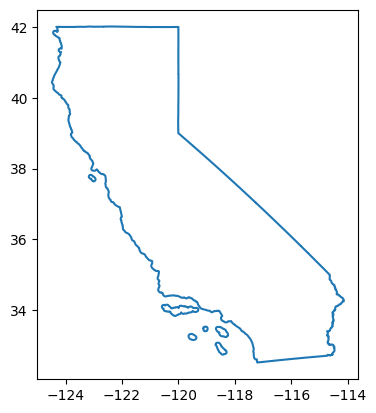

In [16]:
# Create a GeoDataFrame from the data
geometry = [Point(xy) for xy in zip(X['Longitude'], X['Latitude'])]
gdf = gpd.GeoDataFrame(X, geometry=geometry, crs="EPSG:4326")

# Load the California state map
ca_path = '../data/ca_state/CA_State.shp'
california = gpd.read_file(ca_path)
california = california.to_crs("EPSG:4326")
california.boundary.plot()
plt.show()

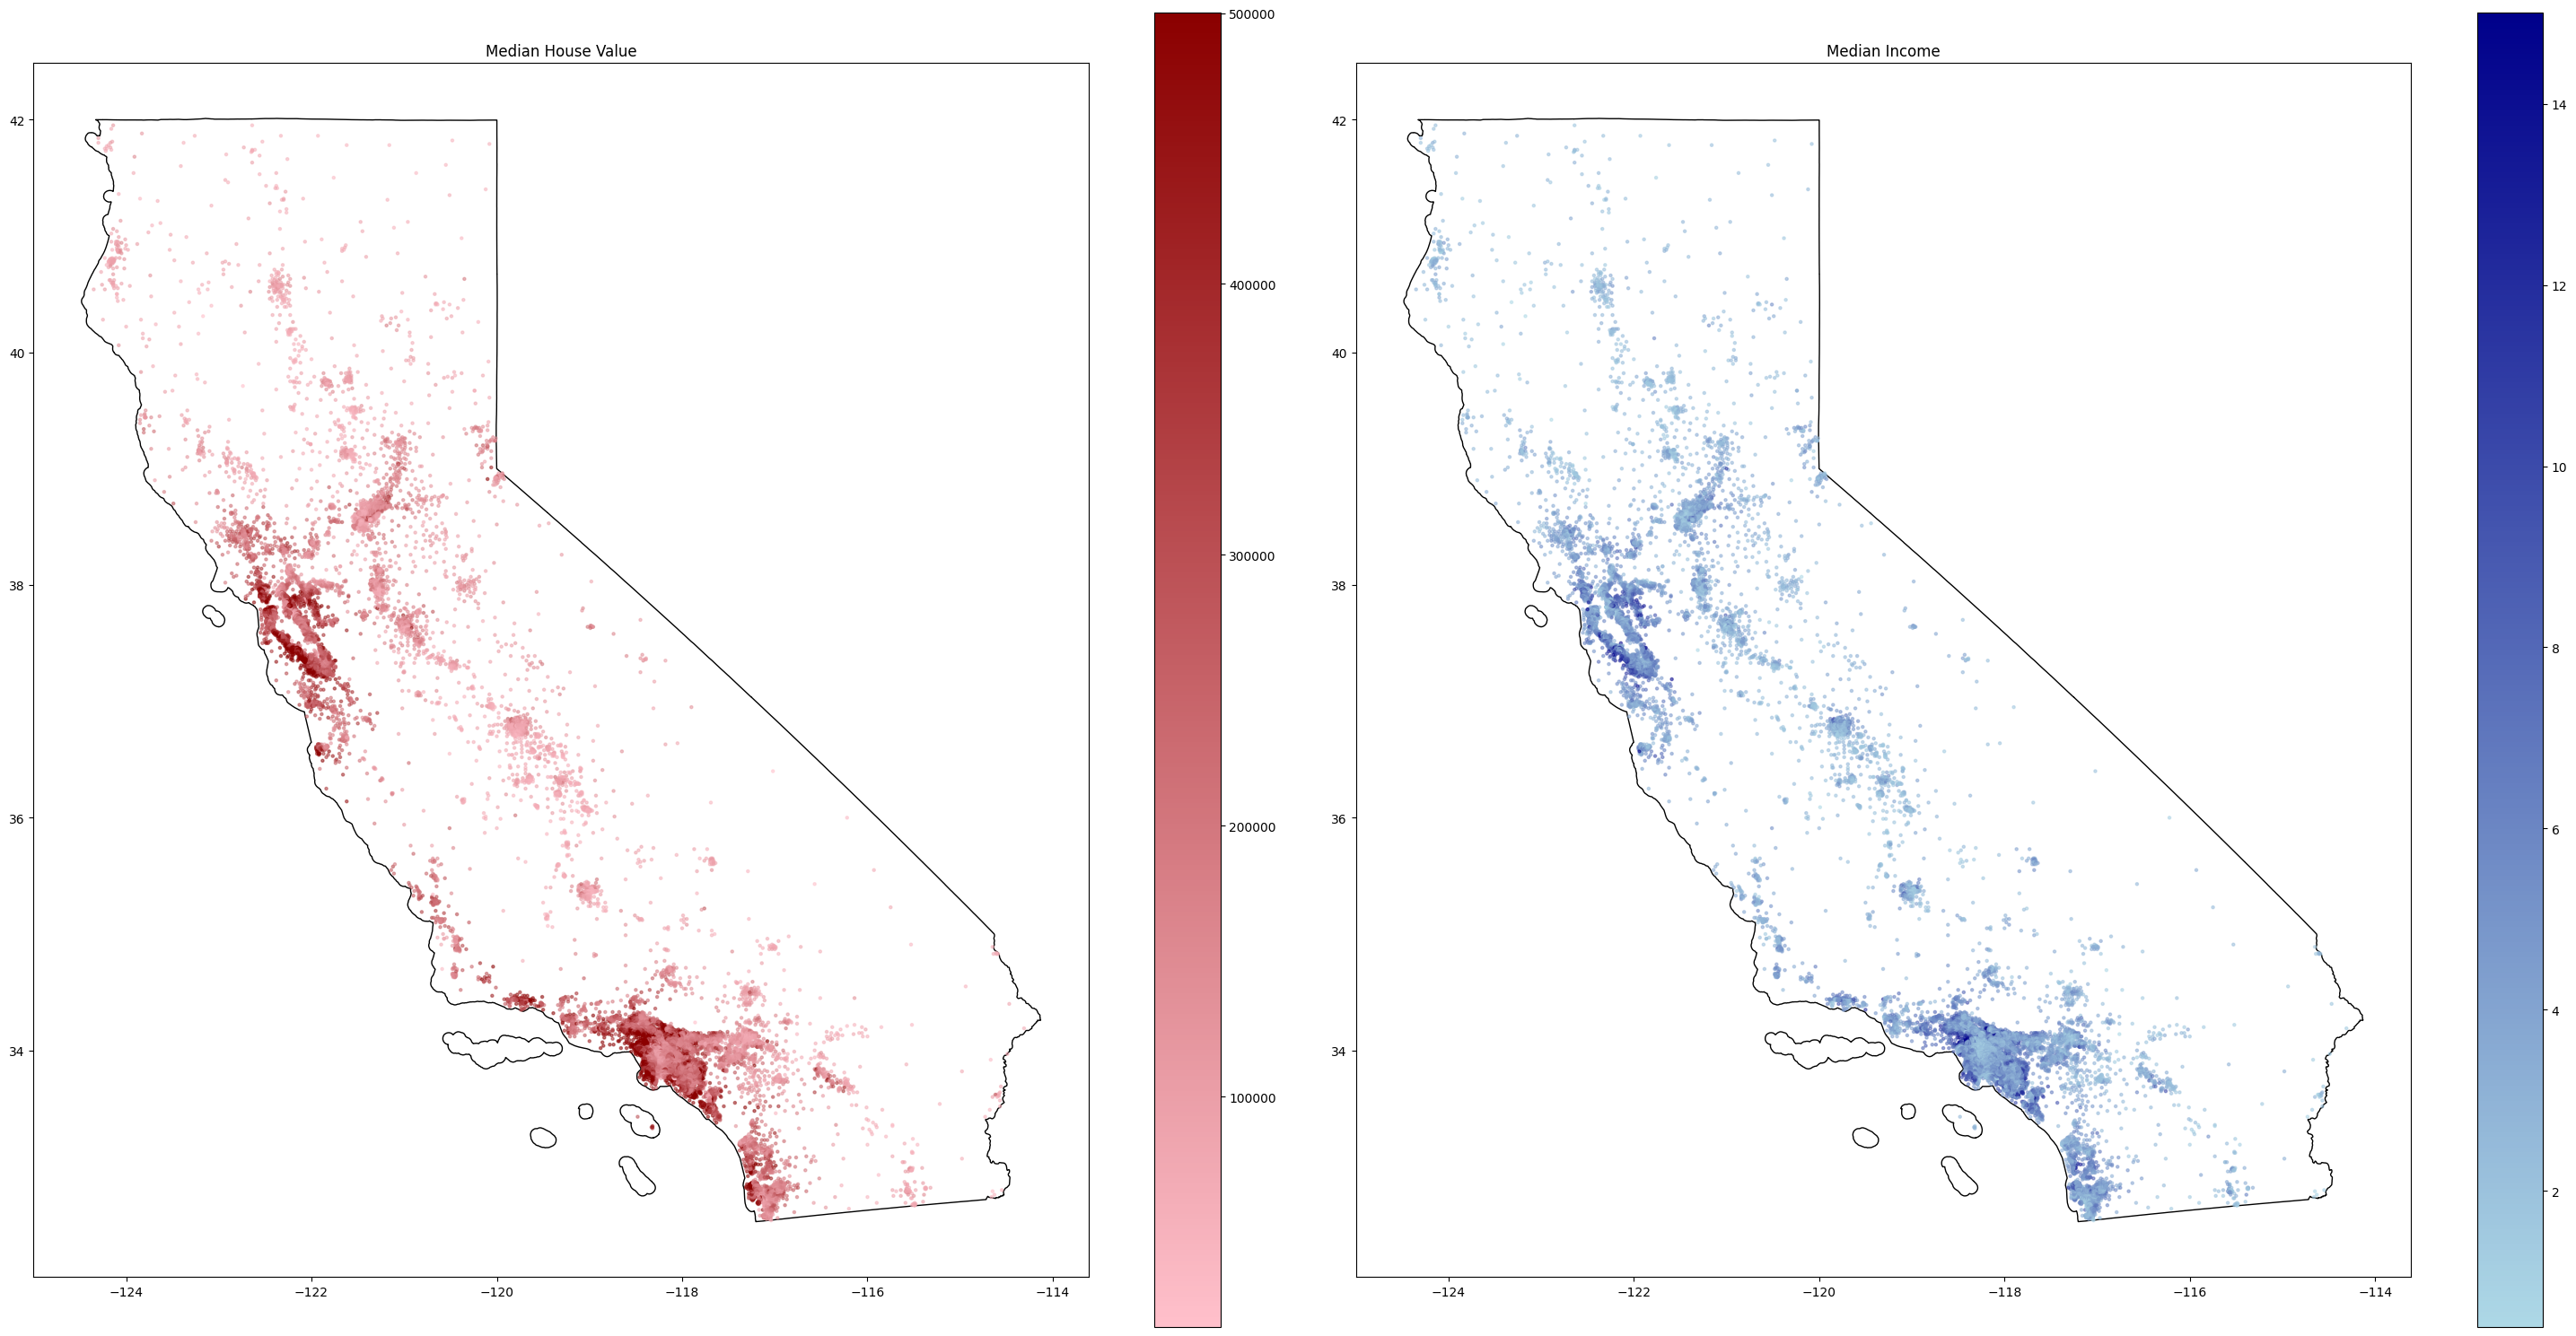

In [21]:

# Define color maps and normalization for each attribute
cmap_house_value = LinearSegmentedColormap.from_list("house_value_cmap", ["pink", "darkred"])
cmap_income = LinearSegmentedColormap.from_list("income_cmap", ["lightblue", "darkblue"])
cmap_distance = plt.get_cmap('coolwarm')

norm_house_value = mcolors.Normalize(vmin=gdf['Median_House_Value'].min(), vmax=gdf['Median_House_Value'].max())
norm_income = mcolors.Normalize(vmin=gdf['Median_Income'].min(), vmax=gdf['Median_Income'].max())
norm_distance = mcolors.Normalize(vmin=gdf['Distance_to_coast'].min(), vmax=gdf['Distance_to_coast'].max())


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# Plot for median house value
base = california.plot(ax=axes[0], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_House_Value', cmap=cmap_house_value, markersize=5, alpha=0.5, legend=True, norm=norm_house_value)
axes[0].set_title('Median House Value')
# axes[0].set_xlabel('Longitude')
# axes[0].set_ylabel('Latitude')

# Plot for median income
base = california.plot(ax=axes[1], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_Income', cmap=cmap_income, markersize=5, alpha=0.5, legend=True, norm=norm_income)
axes[1].set_title('Median Income')
# axes[1].set_xlabel('Longitude')
# axes[1].set_ylabel('Latitude')

# # Plot for distance to coast
# base = california.plot(ax=axes[2], color='white', edgecolor='black')
# gdf.plot(ax=base, marker='o', column='Distance_to_coast', cmap=cmap_distance, markersize=5, alpha=0.5, legend=True, norm=norm_distance)
# axes[2].set_title('Distance to Coast')
# axes[2].set_xlabel('Longitude')
# axes[2].set_ylabel('Latitude')

plt.tight_layout()
plt.show()